In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
X_train = X_train / 255.0
X_test = X_test / 255.0

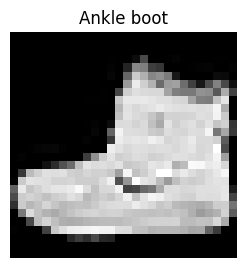

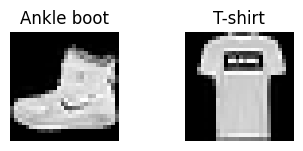

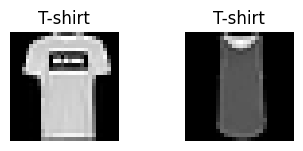

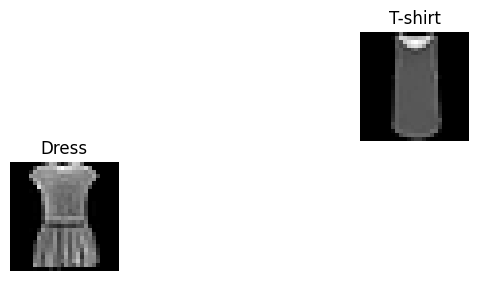

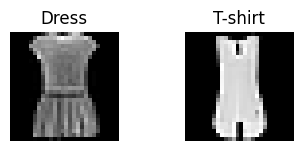

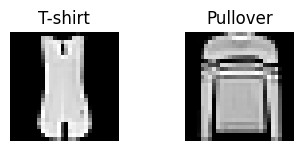

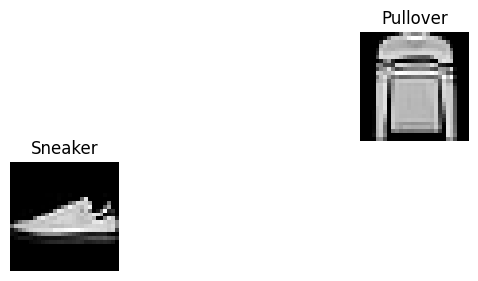

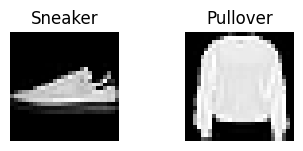

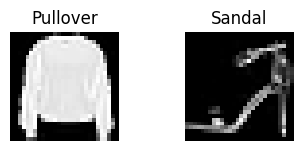

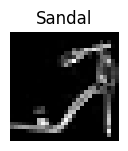

In [4]:
classes = [
"T-shirt",
"Trouser",
"Pullover",
"Dress",
"Coat",
"Sandal",
"Shirt",
"Sneaker",
"Bag",
"Ankle boot"
]

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_train[i], cmap="gray")

    plt.title(classes[y_train[i]])

    plt.axis("off")

    plt.show()
    plt.subplot(3,3,i+1)

    plt.imshow(X_train[i], cmap="gray")

    plt.title(classes[y_train[i]])

    plt.axis("off")
plt.show()

In [5]:
model_under = keras.Sequential([
  keras.layers.Flatten(input_shape=(28,28)),

  keras.layers.Dense(5, activation="relu"),

  keras.layers.Dense(10, activation="softmax")
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
model_under.compile(
  optimizer="adam",

  loss="sparse_categorical_crossentropy",

  metrics=["accuracy"]
)

In [7]:
history_under = model_under.fit(
  X_train,
  y_train,

  epochs=5,

  validation_data=(X_test,y_test)
)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6607 - loss: 0.9335 - val_accuracy: 0.7853 - val_loss: 0.6050
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8065 - loss: 0.5494 - val_accuracy: 0.8026 - val_loss: 0.5605
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8187 - loss: 0.5144 - val_accuracy: 0.8100 - val_loss: 0.5371
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8256 - loss: 0.4973 - val_accuracy: 0.8145 - val_loss: 0.5267
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8291 - loss: 0.4852 - val_accuracy: 0.8172 - val_loss: 0.5132


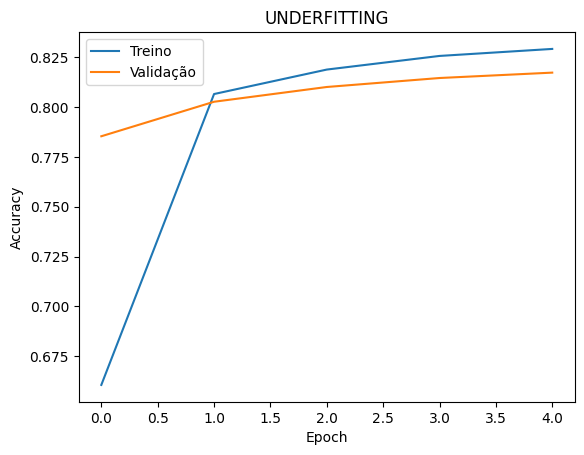

In [8]:
plt.plot(history_under.history['accuracy'], label='Treino')

plt.plot(history_under.history['val_accuracy'], label='Validação')

plt.title("UNDERFITTING")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [9]:
model_over = keras.Sequential([

  keras.layers.Flatten(input_shape=(28,28)),

  keras.layers.Dense(512, activation="relu"),

  keras.layers.Dense(512, activation="relu"),

  keras.layers.Dense(512, activation="relu"),

  keras.layers.Dense(10, activation="softmax")
])

In [10]:
model_over.compile(
  optimizer="adam",

  loss="sparse_categorical_crossentropy",

  metrics=["accuracy"]
)

In [11]:

history_over = model_over.fit(
  X_train,
  y_train,

  epochs=20,

  validation_data=(X_test,y_test)
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - accuracy: 0.8245 - loss: 0.4778 - val_accuracy: 0.8452 - val_loss: 0.4146
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.8656 - loss: 0.3643 - val_accuracy: 0.8708 - val_loss: 0.3685
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.8794 - loss: 0.3255 - val_accuracy: 0.8624 - val_loss: 0.4075
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.8881 - loss: 0.3036 - val_accuracy: 0.8660 - val_loss: 0.3640
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.8930 - loss: 0.2845 - val_accuracy: 0.8732 - val_loss: 0.3595
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.8983 - loss: 0.2719 - val_accuracy: 0.8772 - val_loss: 0.3664
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9037 - loss: 0.2582 - val_accuracy: 0.8820 - val_loss: 0.3546
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9065 -

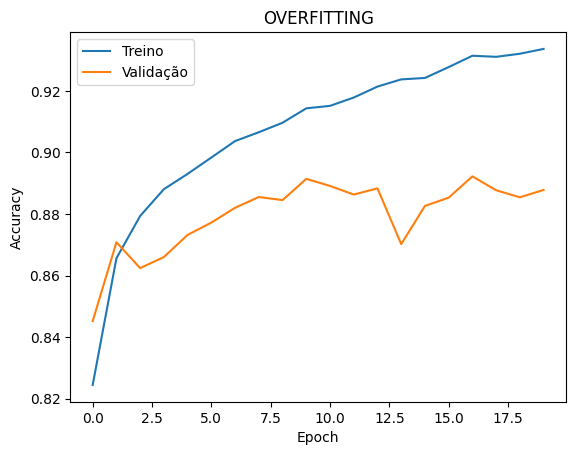

In [12]:
plt.plot(history_over.history['accuracy'], label='Treino')

plt.plot(history_over.history['val_accuracy'], label='Validação')

plt.title("OVERFITTING")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [15]:
model_reg = keras.Sequential([
  keras.layers.Flatten(input_shape=(28,28)),

  keras.layers.Dense(512, activation="relu"),

  keras.layers.Dropout(0.3),

  keras.layers.Dense(512, activation="relu"),

  keras.layers.Dropout(0.3),

  keras.layers.Dense(10, activation="softmax")
])

In [16]:
EarlyStopping early_stop = keras.callbacks.EarlyStopping(
  monitor='val_loss',

  patience=3
)

SyntaxError: invalid syntax (2903833912.py, line 1)

In [ ]:
model_reg.compile(
  optimizer="adam",

  loss="sparse_categorical_crossentropy",

  metrics=["accuracy"]
)

In [ ]:
history_reg = model_reg.fit(
  X_train,
  y_train,

  epochs=20,

  validation_data=(X_test,y_test),

  callbacks=[early_stop]
)

In [ ]:
plt.plot(history_reg.history['accuracy'], label='Treino')

plt.plot(history_reg.history['val_accuracy'], label='Validação')

plt.title("REGULARIZAÇÃO")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()